In [9]:
import tensorflow as tf
import tensorflow.keras.layers as layers
input_data = tf.ones((16, 3, 3))

#stworzenie modelu

# sposób pierwszy

seq_model = tf.keras.Sequential()

# input_shape jest niewymagane, lecz pozwala powiedzieć,
# "chcę mieć taki rozmiar danych wejściowych", co pozwala
# uniknąć głupich pomyłek w stylu: przekazujemy inny rozmiar,
# bo zapomnieliśmy np. zmniejszyć obrazów wejściowych

seq_model.add(layers.Flatten(input_shape=[3, 3]))
seq_model.add(layers.Dense(16, name="input_layer"))
seq_model.add(layers.Dense(32, name="hidden_layer"))
seq_model.add(layers.Dense(4, name="output_layer"))

#sposób drugi

seq_model_2 = tf.keras.Sequential([
    layers.Flatten(),
    layers.Dense(16, name="input_layer"),
    layers.Dense(32, name="hidden_layer"),
    layers.Dense(4, name="output_layer")
])

# uruchomienie naszego modelu z wygenerowanymi danymi
output = seq_model_2(input_data)
print(output)

tf.Tensor(
[[-0.53654873 -1.147417    1.1799235   0.60077196]
 [-0.53654873 -1.147417    1.1799235   0.60077196]
 [-0.53654873 -1.147417    1.1799235   0.60077196]
 [-0.53654873 -1.147417    1.1799235   0.60077196]
 [-0.53654873 -1.147417    1.1799235   0.60077196]
 [-0.53654873 -1.147417    1.1799235   0.60077196]
 [-0.53654873 -1.147417    1.1799235   0.60077196]
 [-0.53654873 -1.147417    1.1799235   0.60077196]
 [-0.53654873 -1.147417    1.1799235   0.60077196]
 [-0.53654873 -1.147417    1.1799235   0.60077196]
 [-0.53654873 -1.147417    1.1799235   0.60077196]
 [-0.53654873 -1.147417    1.1799235   0.60077196]
 [-0.53654873 -1.147417    1.1799235   0.60077196]
 [-0.53654873 -1.147417    1.1799235   0.60077196]
 [-0.53654873 -1.147417    1.1799235   0.60077196]
 [-0.53654873 -1.147417    1.1799235   0.60077196]], shape=(16, 4), dtype=float32)


In [10]:
import numpy as np
import tensorflow as tf

train, test = tf.keras.datasets.fashion_mnist.load_data()

# wydobycie obrazów oraz labelek
images, labels = train

# normalizacja wartości pikseli (maks. wartość
# wynosi 255.0, czyli aby znormalizować nasze dane,
# musimy podzielić każdy piksel przez maks. wartość)
images = images/255.0

# zapisujemy dane jako int
labels = labels.astype(np.int32)

In [11]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
    train_test_split(images, labels, test_size=0.1)

# stworzenie zbioru typu Dataset z naszej listy
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# ustawienie batch_size na 32 oraz przetasowanie na bazie 1000 próbek
train_ds = train_ds.shuffle(1000).batch(32)

In [14]:
f_mnist_model = tf.keras.Sequential([
    layers.Input(shape=(28, 28)),
    # spłaszczanie obrazka do wektora jednowymiarowego
    layers.Flatten(),

    layers.Dense(300, activation='relu'),
    layers.Dense(150, activation='relu'),

    # ostatnia warstwa posiada tyle neuronów ile mamy klas
    layers.Dense(10, activation='softmax')
])
f_mnist_model.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_8 (Flatten)         (None, 784)               0         
                                                                 
 dense_12 (Dense)            (None, 300)               235500    
                                                                 
 dense_13 (Dense)            (None, 150)               45150     
                                                                 
 dense_14 (Dense)            (None, 10)                1510      
                                                                 
Total params: 282160 (1.08 MB)
Trainable params: 282160 (1.08 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [16]:
f_mnist_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
train_stats = f_mnist_model.fit(train_ds, epochs=10, verbose=1)

Epoch 1/10


1688/1688 [==============================] - 5s 3ms/step - loss: 0.4805 - accuracy: 0.8271
Epoch 2/10
1688/1688 [==============================] - 5s 3ms/step - loss: 0.3614 - accuracy: 0.8672
Epoch 3/10
1688/1688 [==============================] - 4s 2ms/step - loss: 0.3249 - accuracy: 0.8791
Epoch 4/10
1688/1688 [==============================] - 4s 3ms/step - loss: 0.3003 - accuracy: 0.8876
Epoch 5/10
1688/1688 [==============================] - 4s 3ms/step - loss: 0.2834 - accuracy: 0.8949
Epoch 6/10
1688/1688 [==============================] - 5s 3ms/step - loss: 0.2685 - accuracy: 0.8986
Epoch 7/10
1688/1688 [==============================] - 5s 3ms/step - loss: 0.2555 - accuracy: 0.9034
Epoch 8/10
1688/1688 [==============================] - 6s 4ms/step - loss: 0.2426 - accuracy: 0.9070
Epoch 9/10
1688/1688 [==============================] - 4s 3ms/step - loss: 0.2311 - accuracy: 0.9129
Epoch 10/10
1688/1688 [==============================] - 5s 3ms/step - loss: 0.2

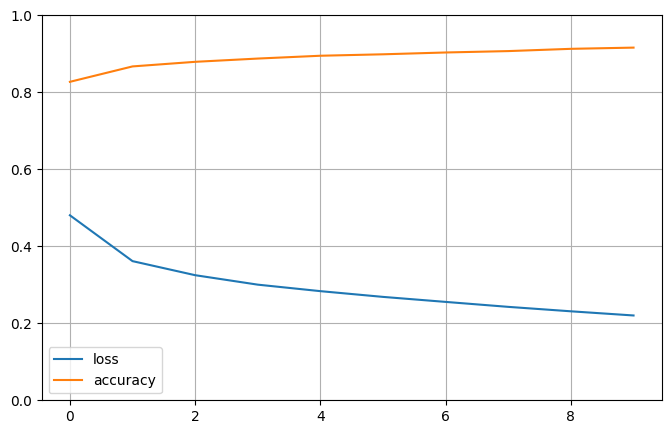

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(train_stats.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [18]:
y_pred = f_mnist_model.predict(X_test)
print("probs : ", y_pred[2])
print("klasa :", np.argmax(y_pred[2]))
print("rzeczywista klasa: ", y_test[2])

"""
probs :  [4.0548810e-15 1.0000000e+00 9.3477974e-17 5.3090128e-13 7.5702587e-15
 5.9295928e-25 2.1536054e-11 3.4459677e-24 2.8725664e-16 2.4974258e-22]
klasa : 1
rzeczywista klasa:  1
"""

188/188 [==============================] - 0s 1ms/step
probs :  [2.09790931e-04 7.89593230e-07 1.06528230e-01 2.11460341e-04
 3.81817631e-02 1.14493455e-08 8.54862809e-01 3.74471076e-09
 5.05978869e-06 2.06509743e-09]
klasa : 6
rzeczywista klasa:  6


'\nprobs :  [4.0548810e-15 1.0000000e+00 9.3477974e-17 5.3090128e-13 7.5702587e-15\n 5.9295928e-25 2.1536054e-11 3.4459677e-24 2.8725664e-16 2.4974258e-22]\nklasa : 1\nrzeczywista klasa:  1\n'

In [19]:
# stworzenie wejścia

input = tf.keras.Input(shape=X_train.shape[1:])

# możemy wypisać, co ta warstwa przyjmuje - jest to rozmiar
# naszego obrazka bez batch_size (który ma wartość None)
print(input)

# spłaszczenie wejścia
input_flat = layers.Flatten(input_shape=[28,28])(input)

# nasza kolejna warstwa jest typu Dense, jak poprzednio, ale od razu
# i bezpośrednio przekazujemy jej wejście, tak jak funkcji w Pythonie:
hidden_1 =layers.Dense(320, activation='relu', name="hidden_1")(input_flat)
hidden_2 =layers.Dense(150, activation='relu', name="hidden_2")(hidden_1)

# złączamy wyniki z obu warstw za pomocą warstwy typu Concatenate
concat_layer = layers.Concatenate()([input_flat, hidden_2])
output = layers.Dense(10, activation='softmax')(concat_layer)

# tworzymy model, przekazując mu co ma być naszymi wyjściami, a co wejściami
model_res = tf.keras.Model(inputs=[input], outputs=[output])

# podsumowanie naszego modelu
model_res.summary()

KerasTensor(type_spec=TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='input_2'), name='input_2', description="created by layer 'input_2'")
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 28, 28)]             0         []                            
                                                                                                  
 flatten_9 (Flatten)         (None, 784)                  0         ['input_2[0][0]']             
                                                                                                  
 hidden_1 (Dense)            (None, 320)                  251200    ['flatten_9[0][0]']           
                                                                                                  
 hidden_2 (Dense)            (None, 150)     

In [20]:
# pamiętajmy, aby nie dodawać pierwszego wymiaru (batch_size)
text = np.array([["ala ma kota"]])

In [21]:
text = np.array([["ala ma kota"]])

input_1 = tf.keras.Input(shape=text.shape[1:])
input_2 = tf.keras.Input(shape=X_train.shape[1:])

# nasza kolejna warstwa jest typu Dense, jak poprzednio,
# ale od razu przekazujemy jej wejście, tak jak funkcji w Pythonie
hidden_1 =layers.Dense(320, activation='relu')(input_1)
hidden_2 =layers.Dense(150, activation='relu')(hidden_1)

# złączamy wyniki naszych warstw za pomocą warstwy
# typu Concatenate podając jako argumenty input_1 oraz hidden_2
concat_layer = layers.Concatenate()([input_1, hidden_2])
output = layers.Dense(10, activation='softmax')(concat_layer)

# tworzymy model, przekazując mu co ma być naszymi wyjściami, a co wejściami
model = tf.keras.Model(inputs=[input_1, input_2], outputs=[output])

# podsumowanie naszego modelu
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 dense_16 (Dense)            (None, 320)                  640       ['input_3[0][0]']             
                                                                                                  
 dense_17 (Dense)            (None, 150)                  48150     ['dense_16[0][0]']            
                                                                                                  
 concatenate_1 (Concatenate  (None, 151)                  0         ['input_3[0][0]',             
 )                                                                   'dense_17[0][0]']      

In [22]:
# kompilacja
model_res.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

#szkolenie na takich samych danych jak poprzednio
train_stats = model_res.fit(train_ds, epochs=10, verbose=1)

Epoch 1/10
1688/1688 [==============================] - 6s 3ms/step - loss: 0.4823 - accuracy: 0.8257
Epoch 2/10
1688/1688 [==============================] - 5s 3ms/step - loss: 0.3654 - accuracy: 0.8655
Epoch 3/10
1688/1688 [==============================] - 5s 3ms/step - loss: 0.3275 - accuracy: 0.8790
Epoch 4/10
1688/1688 [==============================] - 5s 3ms/step - loss: 0.3051 - accuracy: 0.8870
Epoch 5/10
1688/1688 [==============================] - 4s 3ms/step - loss: 0.2843 - accuracy: 0.8943
Epoch 6/10
1688/1688 [==============================] - 5s 3ms/step - loss: 0.2704 - accuracy: 0.8980
Epoch 7/10
1688/1688 [==============================] - 6s 3ms/step - loss: 0.2579 - accuracy: 0.9036
Epoch 8/10
1688/1688 [==============================] - 6s 4ms/step - loss: 0.2451 - accuracy: 0.9069
Epoch 9/10
1688/1688 [==============================] - 5s 3ms/step - loss: 0.2369 - accuracy: 0.9088
Epoch 10/10
1688/1688 [==============================] - 5s 3ms/step - loss: 0.224